# 05 - Purged Walk-Forward Validation

Refit Random Forest on rolling historical windows, predict each next unseen block, and backtest the combined out-of-sample signal stream.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtester import run_backtest, summarize_backtest
from src.data_loader import load_processed_data
from src.features import get_feature_columns
from src.models import train_random_forest
from src.walk_forward import run_walk_forward_validation

In [2]:
dataset = load_processed_data("SPY", PROJECT_ROOT / "data" / "processed")
feature_cols = get_feature_columns(dataset)

walk_forward = run_walk_forward_validation(
    dataset,
    feature_cols,
    train_random_forest,
    target_col="target",
    train_window=1_000,
    test_window=100,
    step_size=100,
    purge_rows=5,
    expanding=False,
)

print(f"OOS rows: {len(walk_forward):,}")
print(f"Folds: {walk_forward['fold'].nunique()}")
print(f"Date range: {walk_forward['date'].min().date()} to {walk_forward['date'].max().date()}")
walk_forward.head()

OOS rows: 3,103
Folds: 32
Date range: 2014-01-30 to 2026-06-02


,source_index,date,close,true_target,future_return,prediction,fold,train_rows,train_start_date,train_end_date,test_start_date,test_end_date,probability_-1,probability_0,probability_1,confidence
0,1005,2014-01-30,145.583008,-1,-0.009764,1,1,1000,2010-02-02,2014-01-22,2014-01-30,2014-06-23,0.272474,0.133441,0.594085,0.594085
1,1006,2014-01-31,144.730072,1,0.008419,1,1,1000,2010-02-02,2014-01-22,2014-01-30,2014-06-23,0.262959,0.150051,0.586991,0.586991
2,1007,2014-02-03,141.472946,1,0.033530,1,1,1000,2010-02-02,2014-01-22,2014-01-30,2014-06-23,0.271669,0.114865,0.613466,0.613466
3,1008,2014-02-04,142.463913,1,0.037573,1,1,1000,2010-02-02,2014-01-22,2014-01-30,2014-06-23,0.186624,0.151924,0.661452,0.661452
4,1009,2014-02-05,142.285172,1,0.039390,1,1,1000,2010-02-02,2014-01-22,2014-01-30,2014-06-23,0.208877,0.149428,0.641695,0.641695


In [3]:
classification_summary = pd.Series(
    {
        "accuracy": accuracy_score(walk_forward["true_target"], walk_forward["prediction"]),
        "macro_f1": f1_score(walk_forward["true_target"], walk_forward["prediction"], average="macro", zero_division=0),
        "average_confidence": walk_forward["confidence"].mean(),
    },
    name="value",
)
classification_summary.to_frame()

,value
accuracy,0.386723
macro_f1,0.360702
average_confidence,0.496050


In [4]:
fold_metrics = (
    walk_forward.groupby("fold")
    .apply(
        lambda fold: pd.Series(
            {
                "rows": len(fold),
                "accuracy": accuracy_score(fold["true_target"], fold["prediction"]),
                "macro_f1": f1_score(fold["true_target"], fold["prediction"], average="macro", zero_division=0),
                "average_confidence": fold["confidence"].mean(),
            }
        ),
        include_groups=False,
    )
)
fold_metrics.describe()

,rows,accuracy,macro_f1,average_confidence
count,32.000000,32.000000,32.000000,32.000000
mean,96.968750,0.375000,0.284168,0.493582
std,17.147339,0.111123,0.096286,0.040696
min,3.000000,0.000000,0.000000,0.414631
25%,100.000000,0.347500,0.233949,0.462334
50%,100.000000,0.385000,0.283910,0.498213
75%,100.000000,0.442500,0.340600,0.522015
max,100.000000,0.550000,0.534589,0.581045


In [5]:
backtest = run_backtest(
    walk_forward,
    prediction_col="prediction",
    price_col="close",
    initial_capital=10_000,
    transaction_cost=0.0005,
    position_size=1.0,
)
backtest_summary = summarize_backtest(backtest)
pd.Series(backtest_summary).to_frame("value")

,value
total_return,-0.633061
cagr,-0.078217
sharpe_ratio,-0.394957
sortino_ratio,-0.365532
max_drawdown,-0.752362
win_rate,0.525510
profit_factor,0.733934
number_of_trades,392.000000
average_trade_return,-0.002162
exposure,0.841766


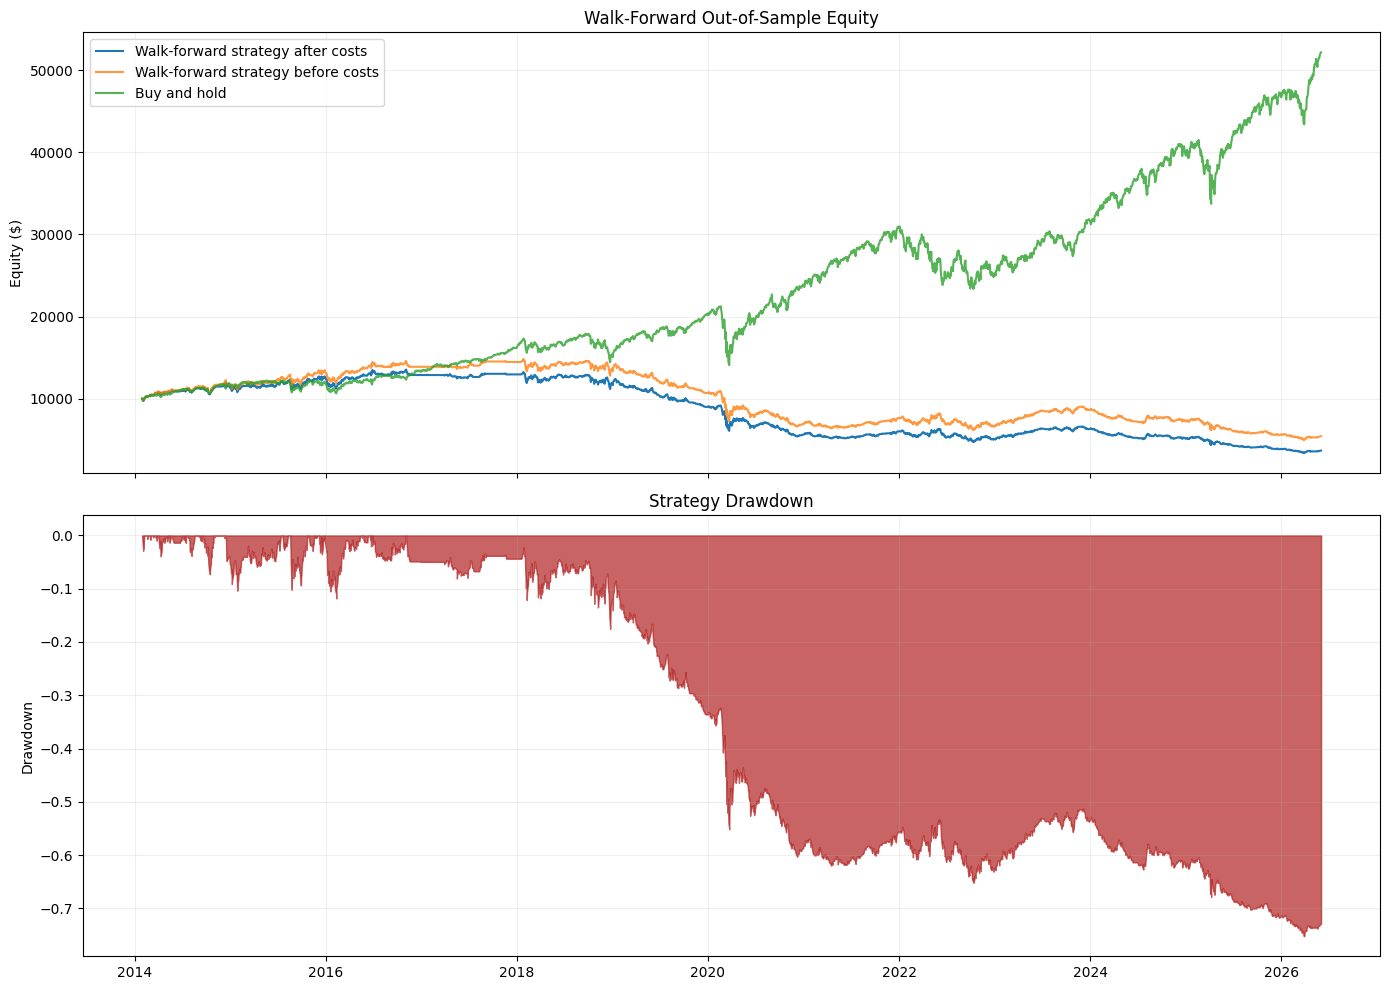

In [6]:
pre_cost_equity = 10_000 * (1 + backtest["strategy_return_before_cost"]).cumprod()

figure, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(backtest["date"], backtest["equity"], label="Walk-forward strategy after costs")
axes[0].plot(backtest["date"], pre_cost_equity, label="Walk-forward strategy before costs", alpha=0.8)
axes[0].plot(backtest["date"], backtest["buy_hold_equity"], label="Buy and hold", alpha=0.8)
axes[0].set_title("Walk-Forward Out-of-Sample Equity")
axes[0].set_ylabel("Equity ($)")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].fill_between(backtest["date"], backtest["drawdown"], 0, color="firebrick", alpha=0.7)
axes[1].set_title("Strategy Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

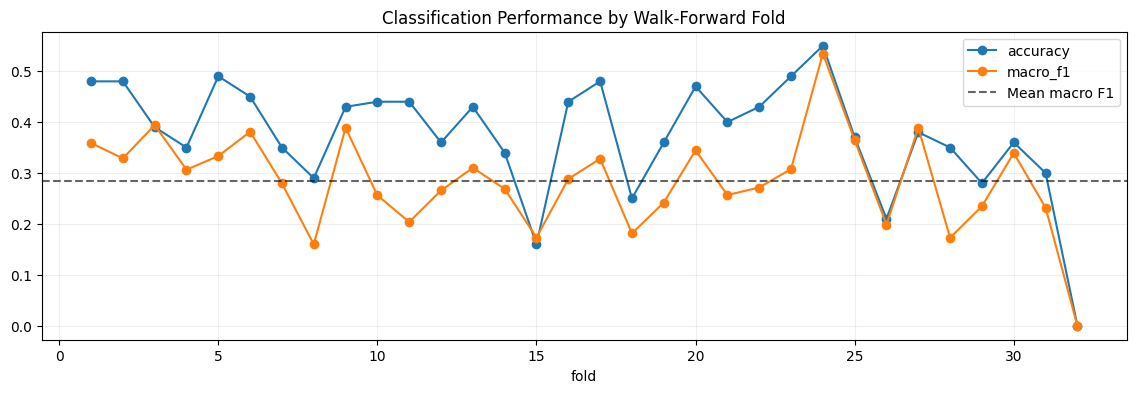

In [7]:
fold_metrics[["accuracy", "macro_f1"]].plot(figsize=(14, 4), marker="o", title="Classification Performance by Walk-Forward Fold")
plt.axhline(fold_metrics["macro_f1"].mean(), color="black", linestyle="--", alpha=0.6, label="Mean macro F1")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Interpretation

Every prediction is produced by a freshly fitted model using only an earlier rolling window. Five rows are purged before every test block so training labels cannot overlap the next test period. This is a stronger estimate of historical robustness than one fixed holdout, but it remains a simulated research result rather than evidence of future profitability.